In [1]:
import sys
sys.path.append('../src')

In [2]:
from integrator import ComplexIntegrator
from context_manager import TriangleIntegrandContext, TriangleIntegrandEvaluator, spherical
from plot_util import plot_complex_integration_with_ref
from wrapped_eval import WrappedEvaluator
from integrand_builder import IntegrandBuilder
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from symbolica import RandomNumberGenerator

# do this to trigger the banner here so it doesn't get in the way later
import oneloop_bridge
oneloop_bridge.set_renormalization_scale(1.0)

########################################################################
#                                                                      #
#                        You are using OneLOop                         #
#                                                                      #
# for the evaluation of 1-loop scalar 1-, 2-, 3- and 4-point functions #
#                                                                      #
# author: Andreas van Hameren <hamerenREMOVETHIS@ifj.edu.pl>           #
#   date: 2024-11-23                                                   #
#                                                                      #
# Please cite                                                          #
#    A. van Hameren,                                                   #
#      Comput.Phys.Commun. 182 (2011) 2427-2438, arXiv:1007.4716       #
#    A. van Hameren, C.G. Papadopoulos and R. Pittau,                  #
#      JHEP 0909:106,2009, arXiv:0903.4665         

In [3]:
ctx = TriangleIntegrandContext()

ib = IntegrandBuilder()
ib.center_counterterm_region_at_origin = False
ib.check_singularities_per_sample = True # not necessary for this example
ib.smooth_mask = True
tie = TriangleIntegrandEvaluator(
    WrappedEvaluator(ib.combined_result(), ib.get_args(), "combined_result"), ctx
)

Compiling evaluator: "combined_result"
Done!


# plot the integrand and threshold subtraction

In [4]:
from context_manager import norm

ctx.set_external_momenta(1, 3, 8)

qs, _ = ctx.get_ordered_qs_and_masses()

threshold_masses = [norm((qs[i]-qs[j])/2)**0.5 for (i,j) in [(0,1), (1,2), (0,2)]]
print(threshold_masses)

[np.float64(0.8660254037844386), np.float64(0.5), np.float64(1.414213562373095)]


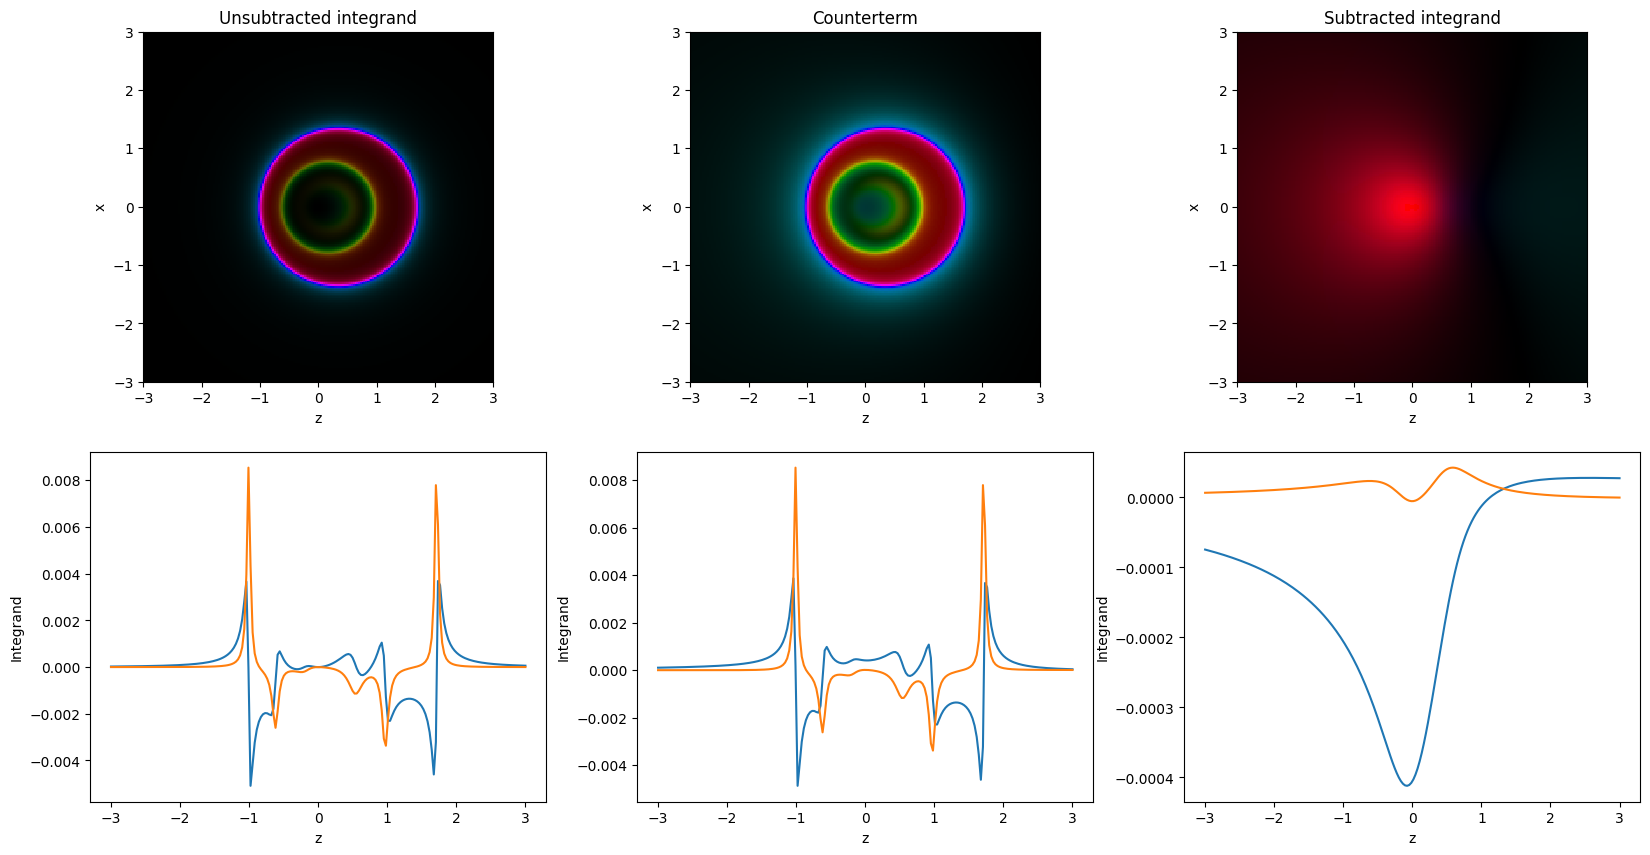

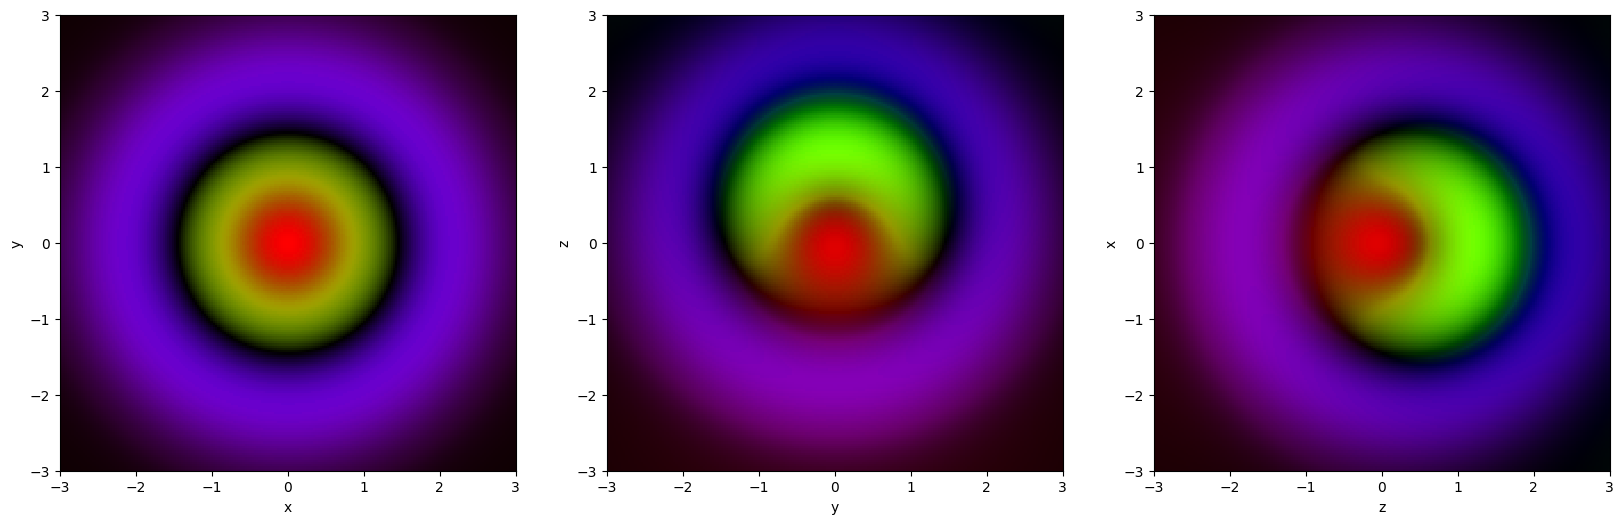

In [5]:
mass = 0.4-0.1j
ctx.masses = [mass, mass, mass]
ctx.threshold = 500
ctx.mask_width = 1
ctx.max_eta_min = 0
tie.plot_threshold_subtraction((-3,3),(-3,3), 2,0)
plt.show()

ctx.combined_integrand()
tie.plot_planes((-3,3),(-3,3), divide_jacobian = True,res = 200)
plt.show()

In [6]:
rng = RandomNumberGenerator(0,0)

In [7]:
def integrate_over_masses(masses, triangle, epochs = 100, steps = 500):
    results = []
    for m in tqdm(masses):
        ctx.masses = [m, m, m]
        
        ci = ComplexIntegrator(3)
        results.append(ci.integrate(triangle.eval, spherical, epochs, steps, rng))
        
        
    return results

def reference_over_masses(masses):
    ref = []
    for m in masses:
        ctx.masses = [m, m, m]
        ref.append(ctx.get_reference())
    return np.array(ref)

In [8]:
mass = 0.4
sample_masses = mass - 0.08j*0.0001**np.linspace(0,1,15)
ref_masses = mass - 0.08j*0.0001**np.linspace(0,1,50)

ctx.combined_integrand()
global_check_res = integrate_over_masses(sample_masses, tie, epochs = 100, steps = 500)

#ctx.only_unsubtracted()
#unsub_res = integrate_over_masses(sample_masses, tie)

ref = reference_over_masses(ref_masses)
ref_same_x = reference_over_masses(sample_masses)

  0%|          | 0/15 [00:00<?, ?it/s]

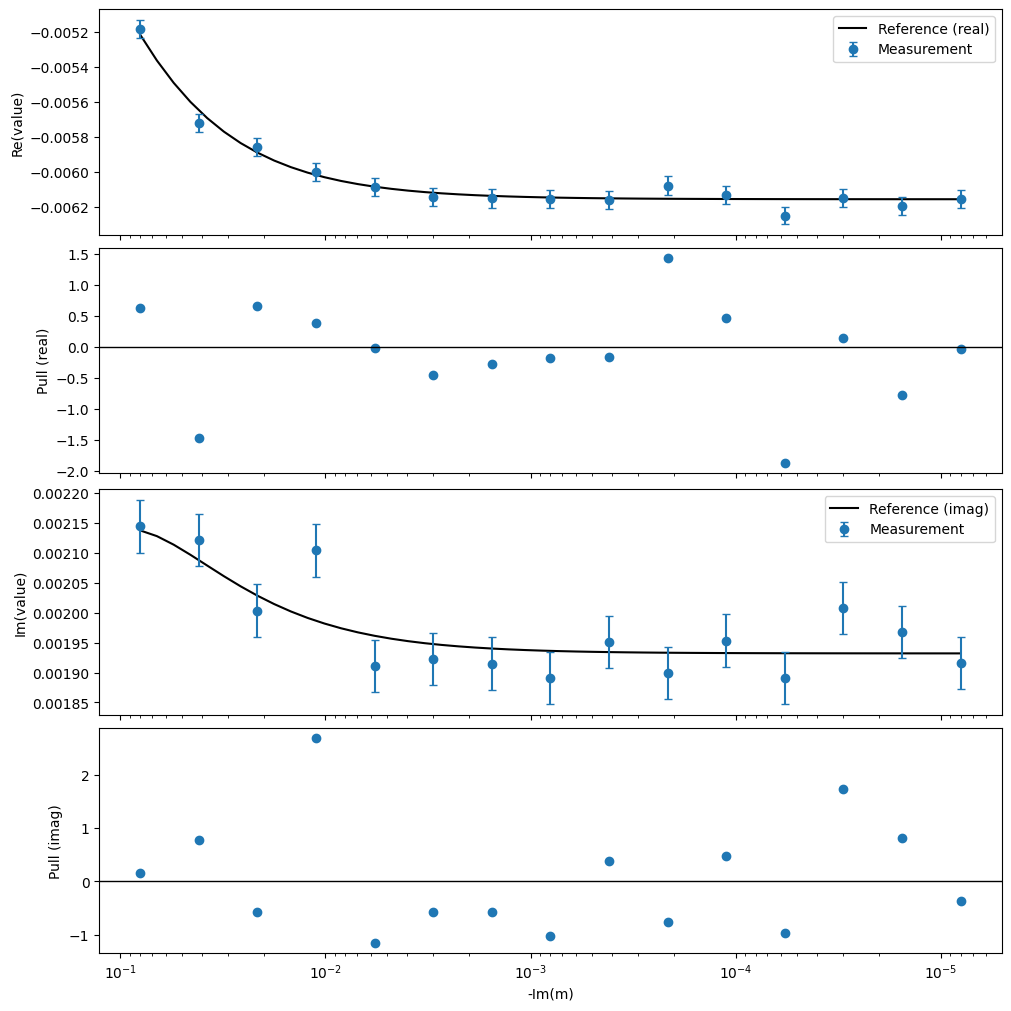

NameError: name 'unsub_res' is not defined

In [9]:
ref = reference_over_masses(ref_masses)
ref_same_x = reference_over_masses(sample_masses)

fig = plot_complex_integration_with_ref(
    global_check_res, ref_same_x, -sample_masses.imag, ref, -ref_masses.imag
)
fig.get_axes()[-1].set_xscale('log')
fig.get_axes()[-1].xaxis.set_inverted(True)
fig.get_axes()[-1].set_xlabel('-Im(m)')
plt.show()

fig = plot_complex_integration_with_ref(
    unsub_res, ref_same_x, -sample_masses.imag, ref, -ref_masses.imag
)
fig.get_axes()[-1].set_xscale('log')
fig.get_axes()[-1].xaxis.set_inverted(True)
fig.get_axes()[-1].set_xlabel('-Im(m)')
plt.show()

In [ ]:
plt.scatter(-sample_masses.imag, [r.cv() for r in unsub_res], label = 'without subtraction', marker='o')
plt.scatter(-sample_masses.imag, [r.cv() for r in global_check_res],  label = 'with subtraction', marker='x')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('-Im(m)')
plt.ylabel('CV')
plt.gca().xaxis.set_inverted(True)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("../images/cv_mass_reg.png", dpi=300)
plt.show()

In [ ]:
sample_masses = np.linspace(0.2,2,15)
ref_masses = np.linspace(0.2,2,200)

ctx.combined_integrand()
ctx.max_eta_min = 0
global_check_res = integrate_over_masses(sample_masses, tie)
ctx.max_eta_min = 0.01
global_check_res_1 = integrate_over_masses(sample_masses, tie)
ctx.max_eta_min = 1e15
global_check_res_2 = integrate_over_masses(sample_masses, tie)


ctx.only_unsubtracted()
unsub_res = integrate_over_masses(sample_masses, tie)

ref = reference_over_masses(ref_masses)

In [ ]:
ref = reference_over_masses(ref_masses)
ref_same_x = reference_over_masses(sample_masses)

fig = plot_complex_integration_with_ref(
    global_check_res, ref_same_x, sample_masses, ref, ref_masses
)
fig.get_axes()[-1].set_xlabel('m')
for m in threshold_masses:
    plt.axvline(m, ls = "--", c = "black")
plt.show()

fig = plot_complex_integration_with_ref(
    unsub_res, ref_same_x, sample_masses, ref, ref_masses
)
fig.get_axes()[-1].set_xlabel('m')
plt.show()

In [ ]:
plt.scatter(sample_masses, unsub_res[-1], label = 'unsubtracted', marker='o')
plt.scatter(sample_masses, global_check_res[-1], label = 'eta min = 0', marker = 'x')
plt.scatter(sample_masses, global_check_res_1[-1], label = 'eta min = 0.01', marker = '.')
plt.scatter(sample_masses, global_check_res_2[-1], label = 'eta min = 1', marker = '.')
plt.yscale('log')
for m in threshold_masses:
    plt.axvline(m, ls = "--", c = "black")
plt.grid(True)
plt.xlabel('m')
plt.ylabel('CV')
plt.legend()
plt.tight_layout()

plt.savefig("../images/cv_threshold_masses.png", dpi=300)
plt.show()


In [ ]:
sample_masses = np.linspace(np.sqrt(2)-0.0005,np.sqrt(2)+0.001,15)
ref_masses = np.linspace(np.sqrt(2)-0.0005,np.sqrt(2)+0.001,200)

ctx.combined_integrand()
ctx.max_eta_min = 0
global_check_res = integrate_over_masses(sample_masses, tie)
ctx.max_eta_min = 0.01
global_check_res_1 = integrate_over_masses(sample_masses, tie)
ctx.max_eta_min = 1e15
global_check_res_2 = integrate_over_masses(sample_masses, tie)


ctx.only_unsubtracted()
unsub_res = integrate_over_masses(sample_masses, tie)

ref = reference_over_masses(ref_masses)

In [ ]:
plt.plot(ref_masses, ref.real, label="reference", c="gray")
plt.errorbar(
    sample_masses,
    global_check_res[0].real,
    global_check_res[1],
    ls="",
    capsize=3,
    elinewidth=3,
    label="eta min = 0",
)
plt.errorbar(
    sample_masses,
    global_check_res_1[0].real,
    global_check_res_1[1],
    ls="",
    capsize=3,
    elinewidth=3,
    label="eta min = 0.01",
)
plt.errorbar(
    sample_masses,
    global_check_res_2[0].real,
    global_check_res_2[1],
    ls="",
    capsize=3,
    elinewidth=3,
    label="eta min = 1",
)
plt.axvline(threshold_masses[2], ls = "--", c = "black")

plt.grid(True)
plt.legend()
plt.xlabel('m')
plt.ylabel('Re(Integral)')
plt.tight_layout()
plt.savefig("../images/threshold_masses_real.png", dpi=300)
plt.show()

plt.plot(ref_masses, ref.imag, label="reference", c="gray")
plt.errorbar(
    sample_masses,
    global_check_res[0].imag,
    global_check_res[2],
    ls="",
    capsize=3,
    elinewidth=3,
    label="eta min = 0",
)
plt.errorbar(
    sample_masses,
    global_check_res_1[0].imag,
    global_check_res_1[2],
    ls="",
    capsize=3,
    elinewidth=3,
    label="eta min = 0.01",
)
plt.errorbar(
    sample_masses,
    global_check_res_2[0].imag,
    global_check_res_2[2],
    ls="",
    capsize=3,
    elinewidth=3,
    label="eta min = 1",
)

plt.axvline(threshold_masses[2], ls = "--", c = "black")

plt.grid(True)
plt.legend()
plt.xlabel('m')
plt.ylabel('Im(Integral)')
plt.tight_layout()
plt.savefig("../images/threshold_masses_imag.png", dpi=300)
plt.show()

In [ ]:
plt.scatter(sample_masses, unsub_res[-1], label = 'unsubtracted', marker='o')
plt.scatter(sample_masses, global_check_res[-1], label = 'eta min = 0', marker = 'x')
plt.scatter(sample_masses, global_check_res_1[-1], label = 'eta min = 0.01', marker = '.')
plt.scatter(sample_masses, global_check_res_2[-1], label = 'eta min = 1', marker = '.')
plt.yscale('log')
plt.grid(True)
plt.xlabel('m')
plt.ylabel('CV')
plt.legend()
plt.tight_layout()

plt.savefig("../images/cv_threshold_masses.png", dpi=300)
plt.show()
